In [27]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import *

In [28]:
# =========================
# LOAD DATASET FROM GITHUB
# =========================

url = "https://raw.githubusercontent.com/thrafid/Assignment5_DT/refs/heads/main/Iris.csv"

df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
# =========================
# PREPROCESSING
# =========================

df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [30]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [31]:
le = LabelEncoder()

# Notice the capital 'S'
df['Species'] = le.fit_transform(df['Species'])

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [32]:
df = df[df['Species'] != 2]

In [33]:
print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [34]:
# =========================
# FEATURE SELECTION
# =========================


X = df[['SepalLengthCm','SepalWidthCm']]
y = df['Species']

In [35]:
# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# =========================
# CART (GINI)
# =========================

cart = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

params = {
    'max_depth':[2,3,4,5,6],
    'min_samples_split':[2,4,6,8]
}

cart_grid = GridSearchCV(
    cart,
    params,
    cv=5,
    scoring='accuracy'
)

cart_grid.fit(X_train,y_train)

best_cart = cart_grid.best_estimator_

print(cart_grid.best_params_)

{'max_depth': 2, 'min_samples_split': 2}


In [37]:
# =========================
# ID3 (ENTROPY)
# =========================

id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

id3_grid = GridSearchCV(
    id3,
    params,
    cv=5,
    scoring='accuracy'
)

id3_grid.fit(X_train,y_train)

best_id3 = id3_grid.best_estimator_

print(id3_grid.best_params_)

{'max_depth': 2, 'min_samples_split': 2}


In [38]:
# =========================
# PREDICTIONS
# =========================

cart_pred = best_cart.predict(X_test)
id3_pred = best_id3.predict(X_test)

cart_prob = best_cart.predict_proba(X_test)[:,1]
id3_prob = best_id3.predict_proba(X_test)[:,1]

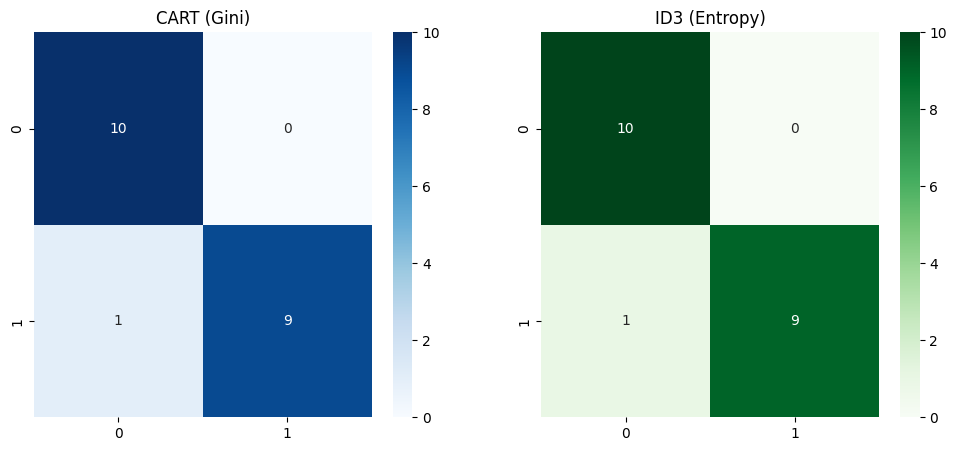

In [39]:
# =========================
# CONFUSION MATRIX
# =========================

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test, cart_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("CART (Gini)")

sns.heatmap(
    confusion_matrix(y_test, id3_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("ID3 (Entropy)")

plt.show()

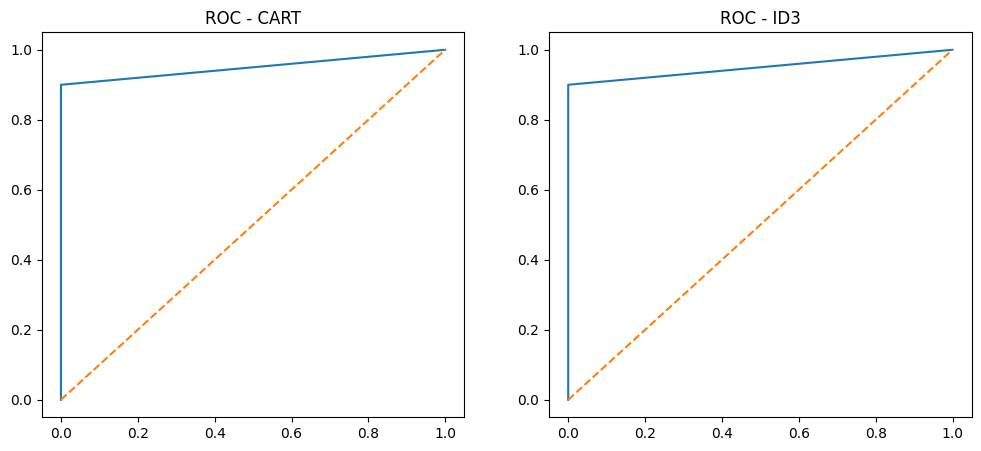

In [40]:
# =========================
# ROC CURVE
# =========================

fpr1, tpr1, _ = roc_curve(y_test, cart_prob)
fpr2, tpr2, _ = roc_curve(y_test, id3_prob)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].plot(fpr1,tpr1)
ax[0].plot([0,1],[0,1],'--')
ax[0].set_title("ROC - CART")

ax[1].plot(fpr2,tpr2)
ax[1].plot([0,1],[0,1],'--')
ax[1].set_title("ROC - ID3")

plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


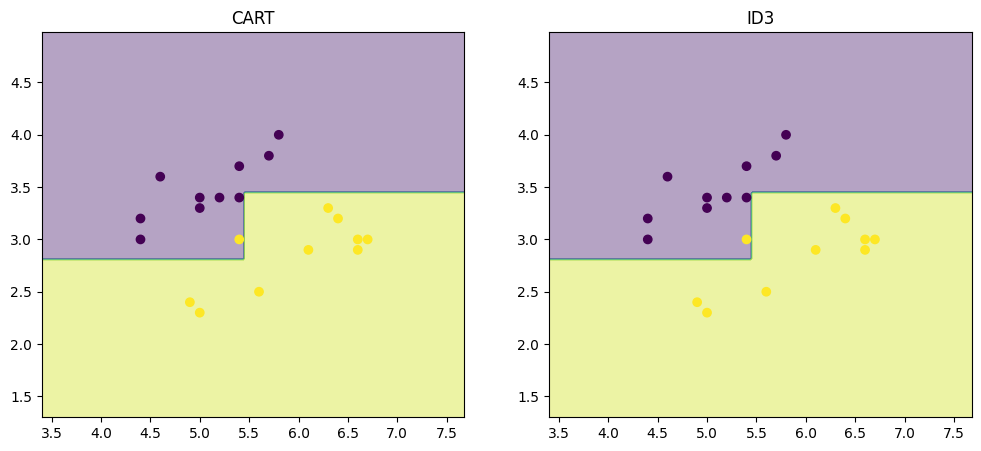

In [41]:
# =========================
# DECISION BOUNDARY
# =========================

def plot_boundary(model, X, y, ax, title):

    x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
    y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min,x_max,0.02),
        np.arange(y_min,y_max,0.02)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    ax.contourf(xx,yy,Z,alpha=0.4)

    ax.scatter(
        X.iloc[:,0],
        X.iloc[:,1],
        c=y
    )

    ax.set_title(title)

fig, ax = plt.subplots(1,2, figsize=(12,5))

plot_boundary(
    best_cart,
    X_test,
    y_test,
    ax[0],
    "CART"
)

plot_boundary(
    best_id3,
    X_test,
    y_test,
    ax[1],
    "ID3"
)

plt.show()


      Metric      CART       ID3
0   Accuracy  0.950000  0.950000
1  Precision  1.000000  1.000000
2     Recall  0.900000  0.900000
3         F1  0.947368  0.947368
4        AUC  0.950000  0.950000


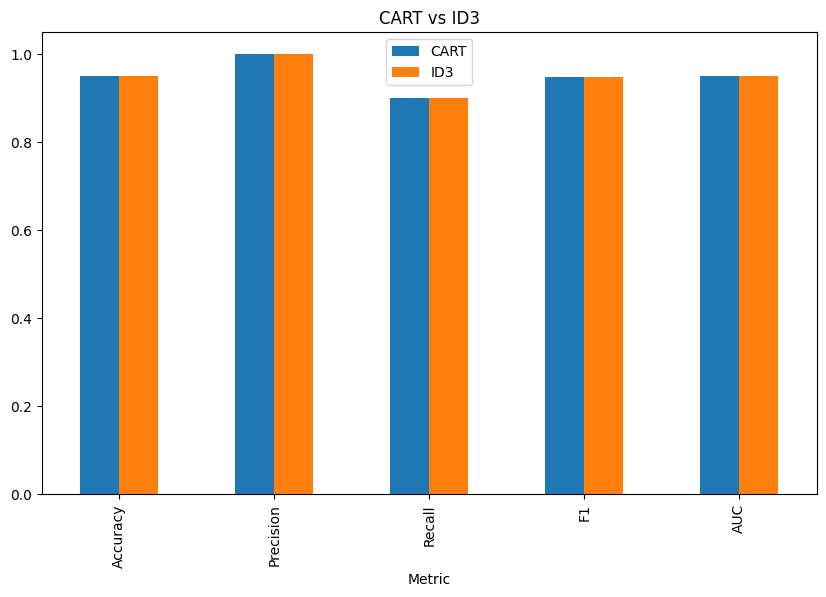

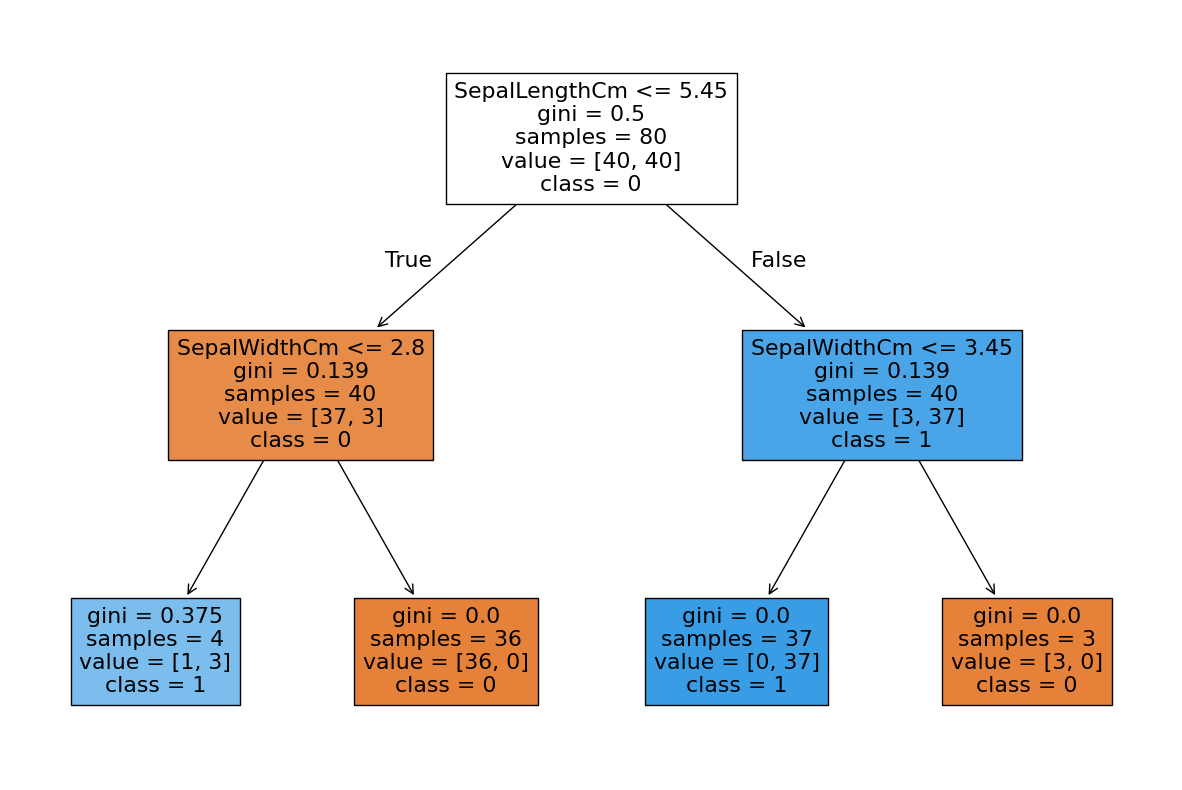

In [42]:
# =========================
# EVALUATION METRICS
# =========================

metrics = pd.DataFrame({

'Metric':['Accuracy','Precision','Recall','F1','AUC'],

'CART':[

accuracy_score(y_test,cart_pred),
precision_score(y_test,cart_pred),
recall_score(y_test,cart_pred),
f1_score(y_test,cart_pred),
roc_auc_score(y_test,cart_prob)

],

'ID3':[

accuracy_score(y_test,id3_pred),
precision_score(y_test,id3_pred),
recall_score(y_test,id3_pred),
f1_score(y_test,id3_pred),
roc_auc_score(y_test,id3_prob)

]
})

print(metrics)

metrics.set_index('Metric').plot(
kind='bar',
figsize=(10,6)
)

plt.title("CART vs ID3")
plt.show()

# =========================
# TREE VISUALIZATION
# =========================

plt.figure(figsize=(15,10))

plot_tree(
    best_cart,
    filled=True,
    feature_names=X.columns,
    class_names=['0','1']
)

plt.show()